# Multi-Label Chest X-Ray Classifier — NIH ChestX-ray14



Downloading dataset (Kaggle API)


In [1]:
from google.colab import files
print("Upload your kaggle.json:")
uploaded = files.upload()  # select kaggle.json from your machine

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Upload your kaggle.json:


Saving kaggle.json to kaggle.json


In [2]:
DATASET = "nih-chest-xrays/sample"   # swap to "nih-chest-xrays/data" for the full 42GB dataset
DATA_ROOT = "/content/nih_data"

!kaggle datasets download -d {DATASET} -p {DATA_ROOT} --unzip

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/sample
License(s): CC0-1.0
100% 4.20G/4.20G [03:29<00:00, 21.5MB/s]



In [3]:
import pandas as pd, os, glob

if DATASET == "nih-chest-xrays/sample":
    df = pd.read_csv(f"{DATA_ROOT}/sample_labels.csv")
    df = df.rename(columns={"Image Index": "Image Index", "Finding Labels": "Finding Labels"})
    df[["Image Index", "Finding Labels"]].to_csv(f"{DATA_ROOT}/Data_Entry_2017.csv", index=False)

    if not os.path.isdir(f"{DATA_ROOT}/images"):
        os.makedirs(f"{DATA_ROOT}/images", exist_ok=True)
        for f in glob.glob(f"{DATA_ROOT}/sample/images/*.png"):
            os.rename(f, f"{DATA_ROOT}/images/{os.path.basename(f)}")

    patient_id = df["Image Index"].str.slice(0, 8)
    unique_patients = patient_id.unique()
    import numpy as np
    rng = np.random.default_rng(0)
    rng.shuffle(unique_patients)
    split_idx = int(0.85 * len(unique_patients))
    train_patients = set(unique_patients[:split_idx])

    train_mask = patient_id.isin(train_patients)
    df.loc[train_mask, "Image Index"].to_csv(f"{DATA_ROOT}/train_val_list.txt", index=False, header=False)
    df.loc[~train_mask, "Image Index"].to_csv(f"{DATA_ROOT}/test_list.txt", index=False, header=False)

print("train images:", sum(1 for _ in open(f"{DATA_ROOT}/train_val_list.txt")))
print("test images:", sum(1 for _ in open(f"{DATA_ROOT}/test_list.txt")))

train images: 4748
test images: 858


Train

In [5]:
from train import train

model, history = train(
    data_root=DATA_ROOT,
    epochs=10,
    batch_size=32,
    lr=1e-4,
    image_size=224,
    freeze_backbone=True,      # trains just the head first, then unfreezes layer
    checkpoint_path="best_model.pth",
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


epoch 1/10  train_loss=0.0158 train_mAUC=0.5341  val_loss=0.0155 val_mAUC=0.5828
  -> new best (val_mAUC=0.5828), saved to best_model.pth
epoch 2/10  train_loss=0.0155 train_mAUC=0.5834  val_loss=0.0153 val_mAUC=0.6189
  -> new best (val_mAUC=0.6189), saved to best_model.pth
[epoch 3] unfroze layer3+, lr -> 1.00e-05
epoch 3/10  train_loss=0.0154 train_mAUC=0.6281  val_loss=0.0150 val_mAUC=0.6423
  -> new best (val_mAUC=0.6423), saved to best_model.pth
epoch 4/10  train_loss=0.0150 train_mAUC=0.6487  val_loss=0.0148 val_mAUC=0.6384
epoch 5/10  train_loss=0.0148 train_mAUC=0.6840  val_loss=0.0146 val_mAUC=0.6455
  -> new best (val_mAUC=0.6455), saved to best_model.pth
epoch 6/10  train_loss=0.0146 train_mAUC=0.6839  val_loss=0.0145 val_mAUC=0.6593
  -> new best (val_mAUC=0.6593), saved to best_model.pth
epoch 7/10  train_loss=0.0144 train_mAUC=0.7034  val_loss=0.0144 val_mAUC=0.6748
  -> new best (val_mAUC=0.6748), saved to best_model.pth
epoch 8/10  train_loss=0.0142 train_mAUC=0.7204  

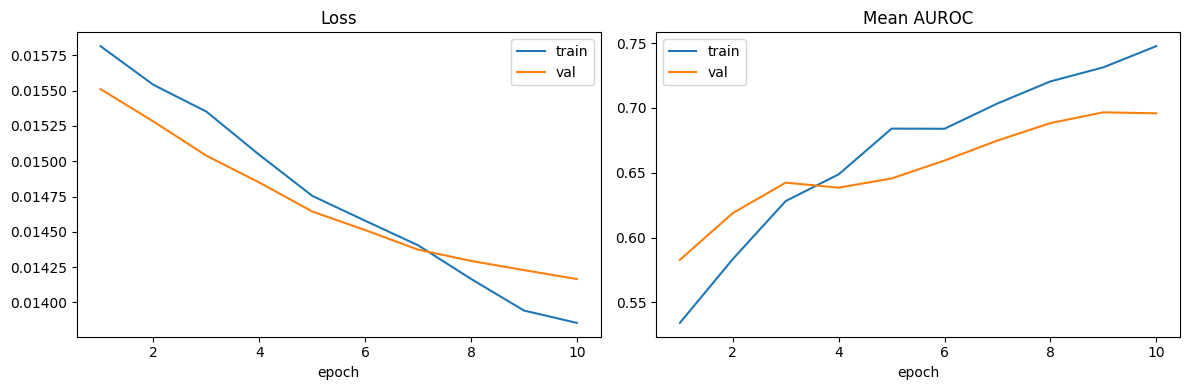

In [6]:
import matplotlib.pyplot as plt

epochs_r = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_r, [h["train_loss"] for h in history], label="train")
axes[0].plot(epochs_r, [h["val_loss"] for h in history], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(epochs_r, [h["train_auc"] for h in history], label="train")
axes[1].plot(epochs_r, [h["val_auc"] for h in history], label="val")
axes[1].set_title("Mean AUROC"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

AUROC on held out set and eval metrics



In [7]:
from train import run_epoch
from data import NIHChestXrayDataset, get_transforms
from losses import MultiLabelFocalLoss, compute_alpha_from_freq
from torch.utils.data import DataLoader
import torch

val_ds = NIHChestXrayDataset(DATA_ROOT, "test_list.txt", transform=get_transforms(False, 224))
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
loss_fn = MultiLabelFocalLoss(alpha=compute_alpha_from_freq(val_ds.labels), gamma=2.0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, mean_auc, per_class_auc = run_epoch(model.to(device), val_loader, loss_fn, device, optimizer=None)

print(f"Mean AUROC: {mean_auc:.4f}\n")
for cls, auc in sorted(per_class_auc.items(), key=lambda x: -x[1]):
    print(f"  {cls:20s} {auc:.4f}")

Mean AUROC: 0.6966

  Edema                0.8199
  Effusion             0.8055
  Hernia               0.8040
  Pneumonia            0.7875
  Consolidation        0.7753
  Atelectasis          0.7536
  Emphysema            0.7419
  Infiltration         0.6932
  Pneumothorax         0.6747
  Cardiomegaly         0.6643
  Pleural_Thickening   0.6422
  Mass                 0.6090
  Nodule               0.5740
  Fibrosis             0.4066


Grad-CAM for interpratibility

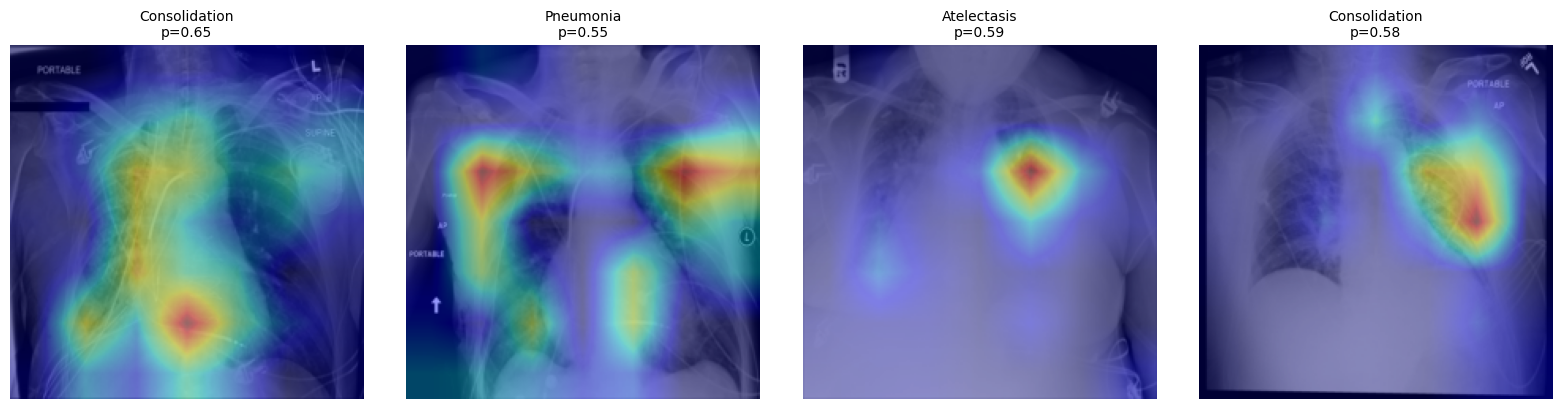

In [8]:
from gradcam import GradCAM, overlay_heatmap
from model import NIH_CLASSES
import numpy as np

cam_engine = GradCAM(model)
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = images[i:i+1]
    probs = model.predict_proba(img)[0]
    top_class_idx = int(probs.argmax())

    heatmap = cam_engine(img, class_idx=top_class_idx)
#display
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    disp = img[0].detach().cpu().permute(1, 2, 0).numpy() * std + mean
    blended = overlay_heatmap(disp, heatmap)

    axes[i].imshow(blended)
    axes[i].set_title(f"{NIH_CLASSES[top_class_idx]}\np={probs[top_class_idx]:.2f}", fontsize=10)
    axes[i].axis("off")

cam_engine.close()
plt.tight_layout(); plt.show()

Gemini API Call for explaination

In [14]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

if api_key is None:
    raise ValueError("GEMINI_API_KEY not found in .env file")
os.environ["GEMINI_API_KEY"] = api_key
from gemini_utils import get_clinical_summary
sample_img, _ = next(iter(val_loader))
sample_img = sample_img[:1].to(device)
probs = model.predict_proba(sample_img)[0].tolist()
note = get_clinical_summary(
    probs,
    patient_context="Adult patient, routine chest film.",
    model_name="gemini-3.1-flash-lite"
)
print(note)

The CNN analysis of this routine chest radiograph reports elevated probability scores across multiple findings, most notably for consolidation (0.65), effusion (0.64), and infiltration (0.61). These metrics suggest a potential overlap in findings, such as the co-occurrence of consolidation and effusion, which frequently appear together in clinical presentations like pneumonia. Please note that these values represent algorithmic output rather than a validated diagnosis and should be interpreted with caution due to the known limitations of the NIH ChestX-ray14 dataset, including potential false positives. This automated output is intended strictly for your review and must be verified by your clinical assessment of the actual images.


Results

In [ ]:
import json
with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)